## Resources

### 🧠 FULL PINN-LSTM CODE (COLAB READY)

### 📦 1. IMPORTS + SETUP

In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [11]:
from google.colab import drive
import pandas as pd

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load the dataset directly from Google Drive
file_name = '/content/drive/MyDrive/TwinPacemaker/NASA Battery Dataset/battery_cycle_level_dataset_CLEAN_FINAL.csv'
df = pd.read_csv(file_name)

print('Loaded:', file_name)
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: /content/drive/MyDrive/TwinPacemaker/NASA Battery Dataset/battery_cycle_level_dataset_CLEAN_FINAL.csv
  battery_id  cycle   voltage  temperature  capacity       soh  rul
0      B0005      1  3.532781    32.536891  1.861976  1.000000  167
1      B0005      2  3.542968    32.643595  1.851862  0.994568  166
2      B0005      3  3.553056    32.522526  1.840808  0.988631  165
3      B0005      4  3.545849    32.492083  1.850058  0.993599  164
4      B0005      5  3.544456    32.368612  1.849432  0.993263  163


### 🧹 3. CLEANING + SORTING

In [12]:
df = df.dropna()
df = df.sort_values(["battery_id", "cycle"])

print("Shape:", df.shape)
print(df.columns)

Shape: (1415, 7)
Index(['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh',
       'rul'],
      dtype='object')


### 🔧 4. FEATURE ENGINEERING (IMPORTANT)

In [13]:
if "current" not in df.columns:
    df["current"] = -0.00001

df["temperature_clipped"] = df["temperature"].clip(30, 45)

df["soc"] = df["capacity"] / df["capacity"].max()

features = ["voltage", "temperature_clipped", "capacity", "soc"]
target_col = "rul"

### 📊 5. NORMALIZATION (CRITICAL FIX)

In [14]:


scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

# normalize RUL (VERY IMPORTANT)
RUL_MAX = df[target_col].max()
df[target_col] = df[target_col] / RUL_MAX

### 🔁 6. SEQUENCE CREATION (FIXED VERSION)

In [15]:
SEQ_LEN = 20

X, y = [], []

for bid, group in df.groupby("battery_id"):
    group = group.sort_values("cycle")

    data = group[features].values
    target = group[target_col].values

    for i in range(len(group) - SEQ_LEN):
        X.append(data[i:i+SEQ_LEN])
        y.append(target[i+SEQ_LEN])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (984, 20, 4)
y shape: (984,)


### ✂️ 7. TRAIN / TEST SPLIT (SAFE VERSION)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 🧠 8. PINN-LSTM MODEL (PRODUCTION ARCHITECTURE)

In [17]:
inputs = keras.Input(shape=(SEQ_LEN, X.shape[2]))

x = layers.LSTM(128, return_sequences=True)(inputs)
x = layers.Dropout(0.2)(x)

x = layers.LSTM(64)(x)
x = layers.Dense(64, activation="relu")(x)

# RUL prediction
rul_output = layers.Dense(1, name="rul_output")(x)

# Physics head (important for PINN constraint)
physics_output = layers.Dense(1, name="physics_output")(x)

model = keras.Model(inputs, outputs=[rul_output, physics_output])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 20, 128)   │     68,096 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 20, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │         65 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_output      │ (None, 1)         │         65 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 121,794 (475.76 KB)

 Trainable params: 121,794 (475.76 KB)

 Non-trainable params: 0 (0.00 B)

### ⚙️ 9. PHYSICS LOSS (REAL BATTERY IDEA)

This enforces degradation consistency:

In [18]:
def physics_loss(x):
    voltage = x[:, -1, 0]
    temp = x[:, -1, 1]
    capacity = x[:, -1, 2]

    # physical degradation proxy
    degradation = capacity / (voltage + 1e-6)

    return tf.reduce_mean(tf.square(degradation - tf.reduce_mean(degradation)))

### 🚀 10. CUSTOM TRAIN STEP (REAL PINN)

In [19]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

@tf.function
def train_step(x, y):
    y = tf.cast(y, tf.float32)

    with tf.GradientTape() as tape:
        rul_pred, phys_pred = model(x, training=True)

        # DATA LOSS (RUL)
        data_loss = tf.reduce_mean(tf.square(y - tf.squeeze(rul_pred)))

        # PHYSICS LOSS
        phys_loss = physics_loss(x)

        # CONSISTENCY LOSS
        consistency_loss = tf.reduce_mean(
            tf.square(tf.stop_gradient(rul_pred) - phys_pred)
        )

        # TOTAL LOSS (BALANCED PINN)
        total_loss = (
            data_loss +
            0.05 * phys_loss +
            0.1 * consistency_loss
        )

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return total_loss

### 🏋️ 11. TRAIN LOOP (CLEAN + STABLE)

In [20]:
EPOCHS = 25

for epoch in range(EPOCHS):
    losses = []

    for i in range(len(X_train)):
        loss = train_step(
            X_train[i:i+1],
            y_train[i:i+1]
        )
        losses.append(loss.numpy())

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {np.mean(losses):.4f}")

Epoch 1/25 - Loss: 0.0352
Epoch 2/25 - Loss: 0.0190
Epoch 3/25 - Loss: 0.0147
Epoch 4/25 - Loss: 0.0132
Epoch 5/25 - Loss: 0.0125
Epoch 6/25 - Loss: 0.0116
Epoch 7/25 - Loss: 0.0112
Epoch 8/25 - Loss: 0.0107
Epoch 9/25 - Loss: 0.0102
Epoch 10/25 - Loss: 0.0100
Epoch 11/25 - Loss: 0.0092
Epoch 12/25 - Loss: 0.0089
Epoch 13/25 - Loss: 0.0083
Epoch 14/25 - Loss: 0.0081
Epoch 15/25 - Loss: 0.0065
Epoch 16/25 - Loss: 0.0062
Epoch 17/25 - Loss: 0.0060
Epoch 18/25 - Loss: 0.0085
Epoch 19/25 - Loss: 0.0059
Epoch 20/25 - Loss: 0.0083
Epoch 21/25 - Loss: 0.0058
Epoch 22/25 - Loss: 0.0053
Epoch 23/25 - Loss: 0.0077
Epoch 24/25 - Loss: 0.0055
Epoch 25/25 - Loss: 0.0048


### 📊 12. EVALUATION

In [ ]:
rul_pred, _ = model.predict(X_test)
rul_pred = rul_pred.squeeze()

# de-normalize
rul_pred = rul_pred * RUL_MAX
y_true = y_test * RUL_MAX

mae = np.mean(np.abs(y_true - rul_pred))
rmse = np.sqrt(np.mean((y_true - rul_pred)**2))

print("MAE:", mae)
print("RMSE:", rmse)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step
MAE: 7.947034
RMSE: 11.00973


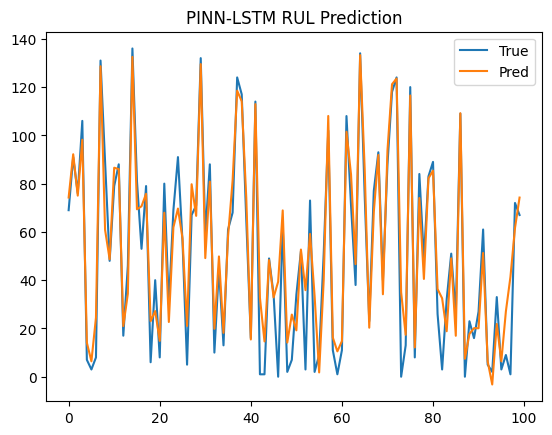

In [ ]:
plt.figure()
plt.plot(y_true[:100], label="True")
plt.plot(rul_pred[:100], label="Pred")
plt.legend()
plt.title("PINN-LSTM RUL Prediction")
plt.show()